In [25]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

import spikeinterface as si
from spikeinterface.sortingcomponents.peak_detection import detect_peaks

import RCP_analysis as rcp
# Adjust if your notebook is not launched from repo root
REPO_ROOT = Path().resolve().parents[0]

PARAMS = rcp.load_experiment_params(
    REPO_ROOT / "config" / "params.yaml",
    repo_root=REPO_ROOT,
)

SESSION_LOC = (Path(PARAMS.data_root) / Path(PARAMS.location)).resolve()
OUT_BASE = SESSION_LOC / "results"
ALIGNED_CKPT_ROOT = OUT_BASE / "checkpoints" / "Aligned"

NPRW_CKPT_OUT = OUT_BASE / "checkpoints" / "NPRW"
UA_CKPT_OUT = OUT_BASE / "checkpoints" / "UA"

FIG_DIR = OUT_BASE / "figures" / "raw_traces_w_peaks"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
nprw_pp_folders = sorted(NPRW_CKPT_OUT.glob("pp_*"))
# pick one for now
nprw_pp_folder = nprw_pp_folders[3]
print(nprw_pp_folder)

ua_pp_folders = sorted(UA_CKPT_OUT.glob("pp__*__NS6"))
# pick one for now
ua_pp_folder = ua_pp_folders[3]
print(ua_pp_folder)

aligned_files = sorted(ALIGNED_CKPT_ROOT.glob("aligned__*__BR_*.npz"))
aligned_npz_path = aligned_files[3]
print(aligned_npz_path)


/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/NPRW/pp_local_30_150__interp_NRR_RW011_251203_141346
/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/UA/pp__NRR_RW011_005__NS6
/home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/checkpoints/Aligned/aligned__NRR_RW011_251203_141346__Intan_004__BR_005.npz


In [ ]:
rec_nprw = si.load(nprw_pp_folder)
rec_ua = si.load(ua_pp_folder)

fs_nprw = float(rec_nprw.get_sampling_frequency())
fs_ua = float(rec_ua.get_sampling_frequency())

print(rec_nprw)
print(f"Sampling rate: {fs_nprw:.1f} Hz")
print(f"Num channels: {rec_nprw.get_num_channels()}")
print(f"Duration: {rec_nprw.get_num_frames() / fs_nprw:.1f} s")

print(rec_ua)
print(f"Sampling rate: {fs_ua:.1f} Hz")
print(f"Num channels: {rec_ua.get_num_channels()}")
print(f"Duration: {rec_ua.get_num_frames() / fs_ua:.1f} s")

BinaryFolderRecording: 128 channels - 30.0kHz - 1 segments - 3,653,376 samples 
                       121.78s (2.03 minutes) - int16 dtype - 891.94 MiB
Sampling rate: 30000.0 Hz
Num channels: 128
Duration: 121.8 s
BinaryFolderRecording: 128 channels - 30.0kHz - 1 segments - 3,538,251 samples 
                       117.94s (1.97 minutes) - int16 dtype - 863.83 MiB
Sampling rate: 30000.0 Hz
Num channels: 128
Duration: 117.9 s


In [18]:
aligned_npz = np.load(aligned_npz_path, allow_pickle=True)
nprw_peak_ms   = aligned_npz["nprw_peak_ms"].item()
nprw_peak_amps = aligned_npz["nprw_peak_amps"].item()

ua_peak_ms   = aligned_npz["ua_peak_ms"].item()
ua_peak_amps = aligned_npz["ua_peak_amps"].item()
ua_meta = aligned_npz["ua_meta"].item()
br_idx = int(ua_meta['session'].split('_')[-1])

print("Keys:", aligned_npz.files)
print("UA peak channels:", len(ua_peak_ms), "NPRW peak channels:", len(nprw_peak_ms))
print("Example UA entry:", next(iter(ua_peak_ms.items())) if len(ua_peak_ms) else None)


METADATA_ROOT = SESSION_LOC / "Metadata"; METADATA_ROOT.mkdir(parents=True, exist_ok=True)
SHIFTS_CSV    = METADATA_ROOT / "br_to_intan_shifts.csv"
br2shift_ms = rcp.get_metadata_mapping(SHIFTS_CSV, 'br_idx', 'shift_ms')
shift_ms = br2shift_ms.get(br_idx, None)
shift_ms


Keys: ['nprw_meta', 'nprw_peak_ms', 'nprw_peak_amps', 'ua_meta', 'ua_peak_ms', 'ua_peak_amps', 'ua_elec', 'ua_region', 'ua_region_names', 'ua_port', 'ua_nsp', 'ua_idx_rows', 'hr_sig', 'vog_sig', 'stim_ms', 'align_meta', 'beh_ns5_sample', 'beh_cam0', 'beh_cam1', 'beh_cam0_cols', 'beh_cam1_cols', 'beh_t_ms', 'ts_state_num', 'ts_state_char']
UA peak channels: 128 NPRW peak channels: 128
Example UA entry: (np.int64(0), array([6.00000000e-01, 2.33333333e+00, 7.00000000e+00, ...,
       9.73118667e+04, 9.73122000e+04, 9.73136667e+04], shape=(46806,)))


'2611.8'

In [12]:
aligned_npz.files

['nprw_meta',
 'nprw_peak_ms',
 'nprw_peak_amps',
 'ua_meta',
 'ua_peak_ms',
 'ua_peak_amps',
 'ua_elec',
 'ua_region',
 'ua_region_names',
 'ua_port',
 'ua_nsp',
 'ua_idx_rows',
 'hr_sig',
 'vog_sig',
 'stim_ms',
 'align_meta',
 'beh_ns5_sample',
 'beh_cam0',
 'beh_cam1',
 'beh_cam0_cols',
 'beh_cam1_cols',
 'beh_t_ms',
 'ts_state_num',
 'ts_state_char']

[saved] /home/bryan/mnt/cullen/Current Project Databases - NHP/2025 Cerebellum prosthesis/Nike/20251203_NRR_RW011/results/figures/raw_traces_w_peaks/raw_traces_w_peaks_CH0_BR005_50-100ms.svg


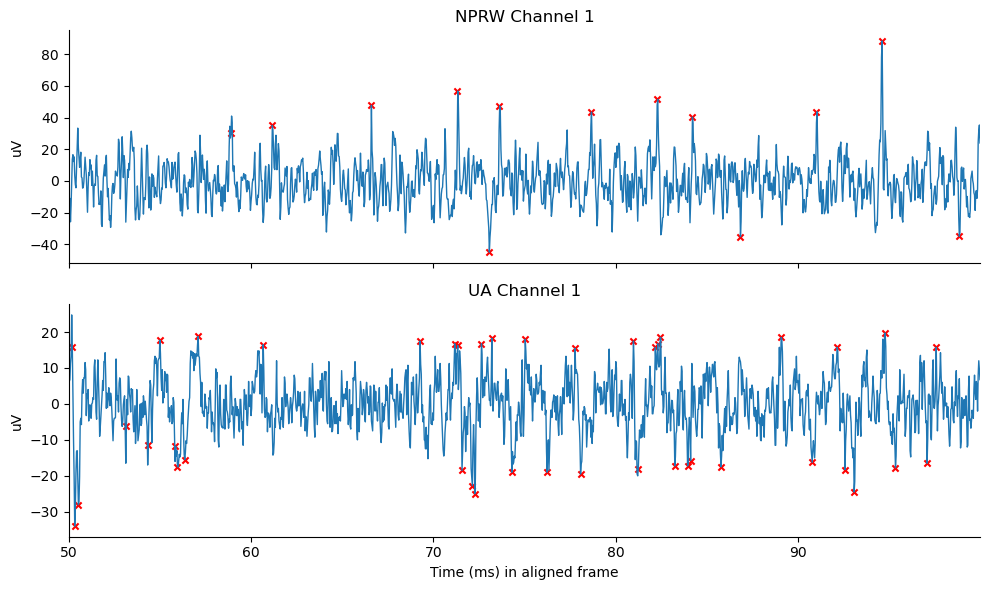

In [34]:
CH = 0
T0_MS, T1_MS = 50, 100
shift_ms = float(shift_ms)

def plot_one(ax, rec, fs, peak_ms_dict, title_prefix,
             window_offset_ms=0.0,
             t_shift_ms=0.0,
             peak_shift_samples=0):
    dt_ms = 1000.0 / fs
    peak_shift_ms = float(peak_shift_samples) * dt_ms

    # ---- choose the segment in REC TIME ----
    w0 = T0_MS + window_offset_ms
    w1 = T1_MS + window_offset_ms

    i0 = int(round(w0 * 1e-3 * fs))
    i1 = int(round(w1 * 1e-3 * fs))
    i0 = max(0, i0)
    i1 = min(rec.get_num_frames(), i1)
    if i1 <= i0:
        ax.set_title(f"{title_prefix}: empty window (check shift/window)")
        ax.axis("off")
        return

    ch_id = rec.get_channel_ids()[CH]
    y = rec.get_traces(start_frame=i0, end_frame=i1, channel_ids=[ch_id], return_in_uV=True).squeeze()

    # ---- build x-axis in REC TIME, then shift to desired frame ----
    t = (np.arange(i0, i1) / fs) * 1000.0
    t = t + t_shift_ms

    # ---- peaks are already in the plotted frame ----
    pk_t = np.asarray(peak_ms_dict.get(CH, []), float) + peak_shift_ms

    m = (pk_t >= t[0]) & (pk_t <= t[-1])
    pk_tw = pk_t[m]

    if pk_tw.size:
        idx = np.searchsorted(t, pk_tw)
        idx = np.clip(idx, 0, y.size - 1)
        ax.scatter(pk_tw, y[idx], s=20, marker="x", color="red",
                   label=f"peaks")

    ax.plot(t, y, lw=1)
    ax.set_xlim(t[0], t[-1])
    ax.set_ylabel("uV")
    ax.set_title(f"{title_prefix} Channel {CH+1}")
    ax.spines[["right", "top"]].set_visible(False)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# NPRW peaks already aligned; shift trace window + axis, and shift peaks by 2 samples
plot_one(
    axes[0], rec_nprw, fs_nprw, nprw_peak_ms, "NPRW",
    window_offset_ms=+shift_ms,
    t_shift_ms=-shift_ms,
    peak_shift_samples=2
)

# UA: no timebase shift; shift peaks by 3 samples
plot_one(
    axes[1], rec_ua, fs_ua, ua_peak_ms, "UA",
    window_offset_ms=0.0,
    t_shift_ms=0.0,
    peak_shift_samples=3
)

axes[1].set_xlabel("Time (ms) in aligned frame")
# axes[0].legend(loc="upper right", frameon=False)


plt.tight_layout()

out_path = FIG_DIR / f"raw_traces_w_peaks_CH{CH}_BR{br_idx:03d}_{T0_MS}-{T1_MS}ms.svg"
fig.savefig(out_path, bbox_inches="tight")   # <-- save FIG, not plt
print(f"[saved] {out_path}")

plt.show()